# PBH population model
---------
We consider the same population as Ng+ 2022 (https://arxiv.org/abs/2204.11864). We fix the number of events to be 600 per year as in the MPSAC study (https://arxiv.org/pdf/2307.10421).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from scipy.stats import lognorm
from scipy.integrate import quad
from scipy.interpolate import interp1d
from scipy.optimize import minimize
from abc import ABC, abstractmethod
from astropy.cosmology import Planck18 as cosmo

%config InlineBackend.figure_format = 'retina'
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 18
})

## Defining the models

### Auxiliary Functions

#### Samplers

In [2]:
def inverse_cdf_sampling(fun, size, prange, res=1e5, seed=42, **kwargs):
    """
    Sample from a probability distribution using inverse cdf sampling.

    :param function fun: PDF to sample from. It has to take an array of values as input and return an array containing their probabilities.
    :param int size: Size of the sample to generate.
    :param tuple prange: Range of the sample to generate.

    :return: Samples extracted from the desired PDF.
    :rtype: array
    """
    np.random.seed(seed)

    # generate uniform samples
    u = np.random.uniform(size=size)

    # compute inverse cdf
    x = np.linspace(prange[0],prange[1], int(res))
    y = fun(x, **kwargs)
    cdf_y = np.cumsum(y)
    cdf_y = cdf_y/cdf_y.max()
    res = np.interp(u, cdf_y,x)
    return res


def inverse_cdf_sampling_uppercond(pdf, lower, upper):

    nSamples = len(upper)
    res = 100000
    eps=1e-02
    x = np.linspace(lower+eps, upper.max()-eps, res)
    cdf = np.cumsum(pdf(x))
    cdf = cdf / cdf[-1]
    probTilUpper = np.interp(upper, x, cdf)
    return np.interp(probTilUpper*np.random.uniform(size=nSamples), cdf, x)


def rejection_sampling_2d(
    target_pdf,
    x_min,
    x_max,
    y_min,
    y_max,
    max_value_M=-1,
    N_samples=10000
):
    """
    Performs rejection sampling for a 2D function f(x, y).

    Args:
        target_pdf: The unnormalized target function (PDF) f(x, y). 
                    Must accept two arguments (x, y).
        x_min, x_max: The boundaries for the x-domain.
        y_min, y_max: The boundaries for the y-domain.
        max_value_M: The maximum value of the target_pdf(x, y) over the domain. 
                     This is the 'M' in the algorithm (f(x, y) <= M).
        N_samples: The desired number of accepted samples.

    Returns:
        A NumPy array of accepted samples of shape (N_accepted, 2), 
        where each row is [x, y].
    """
    
    accepted_samples = []
    iterations = 0
    
    # Check for a valid M
    if max_value_M <= 0:
        #print("Searching for the maximum value (M) of the PDF...")
        
        # We want to maximize f(x, y), which is equivalent to minimizing -f(x, y)
        def negative_target(coords):
            x, y = coords
            # Ensure we stay within bounds (some optimizers might step out)
            if not (x_min <= x <= x_max and y_min <= y <= y_max):
                return 1e12 # Return a large penalty
            return -target_pdf(x, y)

        # Multi-start: Try optimization from 5 different random points
        best_f = -np.inf
        for _ in range(5):
            x0 = np.random.uniform(x_min, x_max)
            y0 = np.random.uniform(y_min, y_max)
            
            res = minimize(
                negative_target, 
                x0=[x0, y0], 
                bounds=[(x_min, x_max), (y_min, y_max)],
                method='L-BFGS-B'
            )
            
            current_max = -res.fun
            if current_max > best_f:
                best_f = current_max

        # Add a small buffer (1%) to M to ensure f(x, y) / M never exceeds 1.0
        max_value_M = best_f * 1.01
        
    print(f"Found M ≈ {max_value_M:.4e}")
    print(f"Starting Rejection Sampling for {N_samples} samples...")
    
    # 1. Proposal Distribution (q(x, y)): A uniform distribution over the domain.
    # q(x, y) = 1 / ((x_max - x_min) * (y_max - y_min))

    while len(accepted_samples) < N_samples:
        iterations += 1
        
        # 2. Draw a proposal sample (x_prop, y_prop) from q(x, y)
        x_prop = np.random.uniform(x_min, x_max)
        y_prop = np.random.uniform(y_min, y_max)
        
        # 3. Calculate the height of the target PDF at the proposal
        f_prop = target_pdf(x_prop, y_prop)
        
        # 4. Draw a random number u from a uniform distribution [0, M]
        # In this implementation, we draw u from [0, 1] and check u < f_prop / M
        u = np.random.rand()
        
        # 5. Acceptance Step: Accept if u * M <= f_prop (or u <= f_prop / M)
        if u <= f_prop / max_value_M:
            accepted_samples.append([x_prop, y_prop])

#    print(f"Sampling complete. Total iterations: {iterations}")
#    print(f"Acceptance rate: {N_samples / iterations * 100:.2f}%")
    
    return np.array(accepted_samples)

#### Merger rate

In [3]:
# ====================================================================
# --- 1. Cosmological Constants and Functions (Planck 2018) ---
# ====================================================================

# H0: Hubble constant (km/s/Mpc)
H0 = 67.4 
# Omega_m: matter density parameter
Om = 0.315 
# Omega_Lambda: dark energy density parameter
Ol = 1.0 - Om
# H0 in units of 1/s (for t(z))
H0_per_s = H0 * 3.240779e-20
# Age of the universe at z=0 (t0) in seconds:
t0_sec = 4.3546e17 # approx 13.8 Gyr in seconds
# c/H0 in Mpc
c_over_H0 = 299792.458 / H0 

def E_z(z):
    """Dimensionless Hubble parameter H(z)/H0."""
    return np.sqrt(Om * (1 + z)**3 + Ol)

def H_z(z):
    """Hubble parameter H(z) in 1/s."""
    return H0_per_s * E_z(z)

def dt_dz_func(z):
    """Time differential dt/dz in seconds."""
    # dt/dz = -1 / ( (1+z) * H(z) )
    return -1.0 / ((1.0 + z) * H_z(z))

def t_z(z):
    """Age of the Universe t(z) in seconds (calculated numerically)."""
    # Integrate dt/dz from z to infinity (or a large z)
    # The age of the universe t(z) is the integral of dt/dz from z=inf to z
    # Since we are integrating dt/dz, t(z) = | integral[z_max to z] dt/dz dz |
    # The integration range needs to be from the start (high z) to z.
    # The age of the universe t0 is t(0).
    
    # We will approximate t(z) by integrating from z to z=1000 (effectively infinity) 
    # and subtracting from the Age of the Universe (t0)

    # Calculate the time elapsed between z=0 and z
    time_elapsed, _ = quad(lambda z_prime: -dt_dz_func(z_prime), 0.0, z)
    
    return t0_sec - time_elapsed

# ====================================================================
# --- 2. PBH Merger Rate and Probability Distribution ---
# ====================================================================

# Exponent for the power-law dependence on cosmic time (from the paper)
RATE_TIME_EXPONENT = -34.0 / 37.0
# Calculate t(z) for a grid and create an interpolator (needed for R_PBH(z))
Z_GRID = np.linspace(5.0, 100.0, 1000)
T_GRID = np.array([t_z(z) for z in Z_GRID])
T0 = T_GRID[0] # Age of the universe at z=0
t_z_interp = interp1d(Z_GRID, T_GRID, kind='cubic')

### Mass distribution

In [4]:
class MassDistribution(ABC):
    '''
    Abstract class to compute mass distributions.

    :param list parameters: List containing the parameters of the mass model.
    :param dict, optional hyperparameters: Dictionary containing the hyperparameters of the mass model as keys and their fiducial value as entry.
    :param dict, optional priorlims_parameters: Dictionary containing the parameters of the mass model as keys and their prior limits value as entry, given as a tuple :math:`(l, h)`.
    '''
    
    def __init__(self, object_type='BBH'):
        self.par_list = []
        self.hyperpar_dict = {}
        self.priorlims_dict = {}
        self.object_type = object_type

    def set_parameters(self, parameters):
        '''
        Setter method for the parameters of the mass model.

        :param list parameters: List containing the parameters of the mass model.
        '''
        self.par_list = parameters

    def set_hyperparameters(self, hyperparameters):
        '''
        Setter method for the hyperparameters of the mass model.

        :param dict new_hyperparameters: Dictionary containing the hyperparameters of the mass model as keys and their new value as entry.
        '''
        self.hyperpar_dict = hyperparameters

    def update_hyperparameters(self, new_hyperparameters):
        '''
        Method to update the hyperparameters of the mass model.

        :param dict new_hyperparameters: Dictionary containing the new hyperparameters of the mass model as keys and their new value as entry.
        '''
        for key in new_hyperparameters.keys():
            if key in self.hyperpar_dict.keys():
                self.hyperpar_dict[key] = new_hyperparameters[key]
            else:
                raise ValueError('The hyperparameter '+key+' is not present in the hyperparameter dictionary.')

    def set_priorlimits(self, limits):
        '''
        Setter method for the prior limits on the parameters of the mass model.

        :param dict limits: Dictionary containing the parameters of the mass model as keys and their prior limits value as entry, given as a tuple :math:`(l, h)`.
        '''
        self.priorlims_dict = limits

    def update_priorlimits(self, new_limits):
        '''
        Method to update the prior limits on the parameters of the mass model.
        
        :param dict new_limits: Dictionary containing the new prior limits on the parameters of the mass model as keys and their new value as entry, given as a tuple :math:`(l, h)`.
        '''
        for key in new_limits.keys():
            if key in self.priorlims_dict.keys():
                self.priorlims_dict[key] = new_limits[key]
            else:
                raise ValueError('The parameter '+key+' is not present in the prior limits dictionary.')

    def _isin_prior_range(self, par,  val):
        '''
        Function to check if a value is in the prior range of a parameter.

        :param str par: Parameter name.
        :param float val: Parameter value.
        :return: Boolean value.
        :rtype: bool
        '''

        return (val >= self.priorlims_dict[par][0]) & (val <= self.priorlims_dict[par][1])
    
    @abstractmethod
    def mass_function(self,):
        '''
        Mass function of the model.

        :return: Mass function value.
        :rtype: float
        '''
        pass

    @abstractmethod
    def sample_population(self, size):
        '''
        Function to sample the mass distribution.

        :param int size: number of samples
        '''
        pass


class PBHMergerMassFunction(MassDistribution):
    '''
    Parameters:
        * M_c: Central Mass Scale of the lognormal distribution (M_sun).
        * sigma: Width of the lognormal distribution (M_sun).
        * m_min: Minimum mass to consider (M_sun).
        * m_max: Maximum mass to consider (M_sun).
    
    :param list parameters: List containing the parameters of the mass model.
    :param dict, optional hyperparameters: Dictionary containing the hyperparameters of the mass model as keys and their fiducial value as entry.
    :param dict, optional priorlims_parameters: Dictionary containing the parameters of the mass model as keys and their prior limits value as entry, given as a tuple :math:`(l, h)`.

    '''

    def __init__(self, hyperparameters=None, priorlims_parameters=None):

        self.expected_hyperpars = ['M_c', 'sigma', 'm_min', 'm_max']
        super().__init__()

        self.set_parameters(['m1_src', 'm2_src'])

        if hyperparameters is not None:
            self.set_hyperparameters(hyperparameters)
        else:
            print('Expected hyperparameters: ', self.expected_hyperpars)
            basevalues = {'M_c':30., 'sigma':0.3, 'm_min':1., 'm_max':100.}
            print('Base values are: ', list(basevalues.items()))
            self.set_hyperparameters(basevalues)
        
        if priorlims_parameters is not None:
            self.set_priorlimits(priorlims_parameters)
        else:
            # Define the prior limits for 'm1_src' and 'q'
            self.set_priorlimits({'m1_src': (1., 100.), 'm2_src': (1., 100.)})


    def mass_function(self, m1_src, m2_src, M_c=None, sigma=None, m_min=None, m_max=None, uselog=False):
        '''
        Mass distribution of the objects.
        
        :param array m1_src: Primary mass.
        :param array m2_src: Secondary mass.
        :param float, optional M_c: Central Mass Scale of the lognormal distribution (M_sun).
        :param float, optional sigma: Width of the lognormal distribution (M_sun).
        :param float, optional m_min: Minimum mass to consider (M_sun).
        :param float, optional m_max: Maximum mass to consider (M_sun).
        :param bool, optional uselog: Boolean specifying whether to return the probability or log-probability, defaults to False.
        
        :return: Mass function value at the input masses.
        :rtype: array
        '''

        M_c = self.hyperpar_dict['M_c'] if M_c is None else M_c
        sigma  = self.hyperpar_dict['sigma'] if sigma is None else sigma
        mmin  = self.hyperpar_dict['m_min'] if m_min is None else m_min
        mmax  = self.hyperpar_dict['m_max'] if m_max is None else m_max

        TARGET_EXP_SUM = -36.0 / 37.0
        TARGET_EXP_PROD = -32.0 / 37.0

        lognorm_dist = lognorm(s=sigma, scale=M_c)

        return (m1_src + m2_src)**TARGET_EXP_SUM * (m1_src * m2_src)**TARGET_EXP_PROD * lognorm_dist.pdf(m1_src) * lognorm_dist.pdf(m2_src)
    
        
    def sample_population(self, size):

        m_min = self.hyperpar_dict['m_min']
        m_max = self.hyperpar_dict['m_max']

        target_function = lambda m1, m2: self.mass_function(m1, m2)
        m1_src, m2_src = rejection_sampling_2d(target_function, m_min, m_max, m_min, m_max, N_samples=size).T

        return {'m1_src':m1_src, 'm2_src':m2_src}


### Redshift distribution

In [5]:
# This is to avoid calling astropy during minimization, improves speed
zGridGLOB = np.logspace(start=-10, stop=3, base=10, num=1000)
dLGridGLOB = cosmo.luminosity_distance(zGridGLOB).value/1e3 # in Gpc
dVcomGridGLOB = 4.*np.pi*cosmo.differential_comoving_volume(zGridGLOB).value/1e9 # in Gpc^3

class RateDistribution(ABC):
    '''
    Abstract class to compute redshift distributions.

    :param dict, optional hyperparameters: Dictionary containing the hyperparameters of the redshift model as keys and their fiducial value as entry.
    :param dict, optional priorlims_parameters: Dictionary containing the parameters of the redshift model as keys and their prior limits value as entry, given as a tuple :math:`(l, h)`.
    
    '''

    def __init__(self,):
        
        self.par_list = ['z']
        self.hyperpar_dict = {}
        self.priorlims_dict = {}
    
    def set_hyperparameters(self, hyperparameters):
        '''
        Setter method for the hyperparameters of the redshift model.

        :param dict new_hyperparameters: Dictionary containing the hyperparameters of the redshift model as keys and their new value as entry.
        '''
        self.hyperpar_dict = hyperparameters

    def update_hyperparameters(self, new_hyperparameters):
        '''
        Method to update the hyperparameters of the redshift model.

        :param dict new_hyperparameters: Dictionary containing the new hyperparameters of the redshift model as keys and their new value as entry.
        '''
        for key in new_hyperparameters.keys():
            if key in self.hyperpar_dict.keys():
                self.hyperpar_dict[key] = new_hyperparameters[key]
            else:
                raise ValueError('The hyperparameter '+key+' is not present in the hyperparameter dictionary.')
            
    def set_priorlimits(self, limits):
        '''
        Setter method for the prior limits on the parameters of the redshift model.

        :param dict limits: Dictionary containing the parameters of the redshift model as keys and their prior limits value as entry, given as a tuple :math:`(l, h)`.
        '''
        # This is to avoid numerical issues with the rate function when interpolating the differential comoving volume
        eps = 1e-6
        if limits['z'][0] < eps:
            limits['z'] = (eps, limits['z'][1])
        self.priorlims_dict = limits
        
    def update_priorlimits(self, new_limits):
        '''
        Method to update the prior limits on the parameters of the redshift model.
        
        :param dict new_limits: Dictionary containing the new prior limits on the parameters of the redshift model as keys and their new value as entry, given as a tuple :math:`(l, h)`.
        '''
        eps = 1e-6
        for key in new_limits.keys():
            if key in self.priorlims_dict.keys():
                if (key == 'z') & (new_limits['z'][0] < eps):
                    new_limits['z'] = (eps, new_limits['z'][1])
                self.priorlims_dict[key] = new_limits[key]
            else:
                raise ValueError('The parameter '+key+' is not present in the prior limits dictionary.')

    def _isin_prior_range(self, par,  val):
        """
        Function to check if a value is in the prior range of a parameter.

        :param str par: Parameter name.
        :param float val: Parameter value.
        :return: Boolean value.
        :rtype: bool
        """

        return (val >= self.priorlims_dict[par][0]) & (val <= self.priorlims_dict[par][1])
    
    @abstractmethod
    def rate_function(self, z):
        pass

    @abstractmethod
    def sample_population(self, size):
        pass


class PBHMergerRateFunction(RateDistribution):

    def __init__(self, hyperparameters=None, priorlims_parameters=None):
        
        self.expected_hyperpars = ['alpha_z']
        super().__init__()

        if hyperparameters is not None:
            self.set_hyperparameters(hyperparameters)
        else:
            print('Expected hyperparameters: ', self.expected_hyperpars)
            basevalues = {'alpha_z':34.0 / 37.0}
            print('Base values are: ', list(basevalues.items()))
            self.set_hyperparameters(basevalues)
        
        if priorlims_parameters is not None:
            self.set_priorlimits(priorlims_parameters)
        else:
            self.set_priorlimits({'z': (5., 100.)})

        self.derivative_par_nums = {'alpha_z':0}

    def _pbh_rate(self, z, alpha_z=None, R0=1.0):
        '''
        Comoving merger rate density R_PBH(z) proportional to (t(z)/t0)^(-34/37).
        Returns an unnormalized rate.
        '''
        alpha = self.hyperpar_dict['alpha_z'] if alpha_z is None else alpha_z
        
        t_ratio = t_z_interp(z) / T0
        return R0 * t_ratio**(-alpha)
    
    def rate_function(self, z, alpha_z=None):
        '''
        Intrinsic probability density for a merger to occur in a comoving volume at z.
        P_int(z) \propto R_PBH(z) * dVc/dz(z)
        '''

        alpha = self.hyperpar_dict['alpha_z'] if alpha_z is None else alpha_z

        goodsamples = self._isin_prior_range('z', z)
        zgrid = np.geomspace(self.priorlims_dict['z'][0], self.priorlims_dict['z'][1], 1000)

        distr = self._pbh_rate(z, alpha, 1.)*np.interp(z, zGridGLOB, dVcomGridGLOB)/(1.+z)
        norm  = np.trapz(self._pbh_rate(zgrid, alpha, 1.)*np.interp(zgrid, zGridGLOB, dVcomGridGLOB)/(1.+zgrid), zgrid)    

        return np.where(goodsamples, distr/norm, 0.)
    
    def sample_population(self, size):
        '''
        Function to sample the redshift model.
        
        :param int size: Size of the redshift sample.

        :return: Sampled redshifts and corresponding luminosity distances in :math:`{\\rm Gpc}`.
        :rtype: dict(array, array)
        '''
        
        z = inverse_cdf_sampling(self.rate_function, size, self.priorlims_dict['z'])
        
        dL = np.interp(z, zGridGLOB, dLGridGLOB)
        
        return {'z':z, 'dL':dL}

<>:124: SyntaxWarning: invalid escape sequence '\p'
<>:124: SyntaxWarning: invalid escape sequence '\p'
/var/folders/04/59g9g55x7qqcmhl8pk4ctcf40000gn/T/ipykernel_55748/142796703.py:124: SyntaxWarning: invalid escape sequence '\p'
  P_int(z) \propto R_PBH(z) * dVc/dz(z)


## Sampling the STM population

### Mass

In [18]:
mymassdist = PBHMergerMassFunction(hyperparameters={'M_c':30.0, 'sigma':0.3, 'm_min':1., 'm_max':100.})
samples = mymassdist.sample_population(size=600)

Found M ≈ 1.0707e-07
Starting Rejection Sampling for 600 samples...


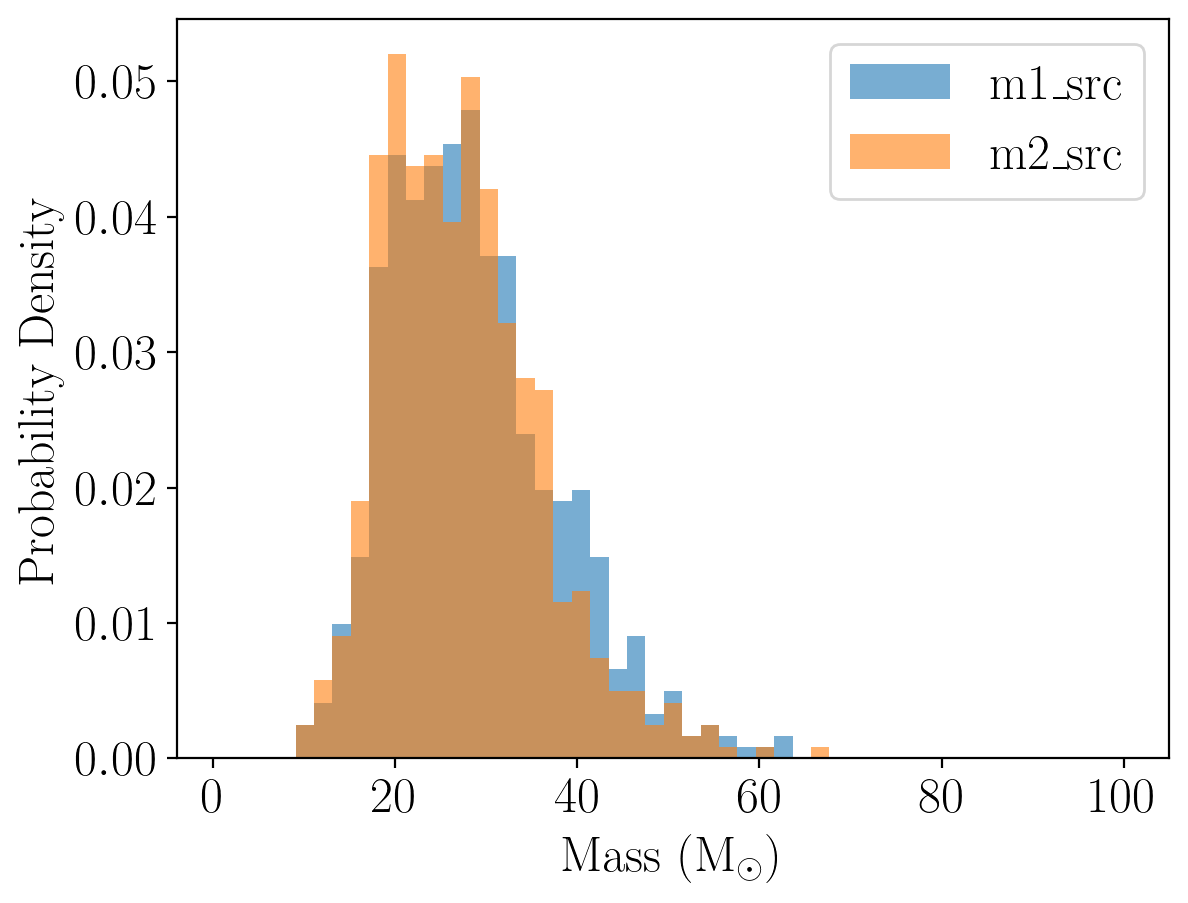

In [19]:
bins = np.linspace(1, 100, 50)
plt.hist(samples['m1_src'], bins=bins, alpha=0.6, label='m1_src', density=True)
plt.hist(samples['m2_src'], bins=bins, alpha=0.6, label='m2_src', density=True)
plt.xlabel('Mass (M$_\\odot$)')
plt.ylabel('Probability Density')
plt.legend()

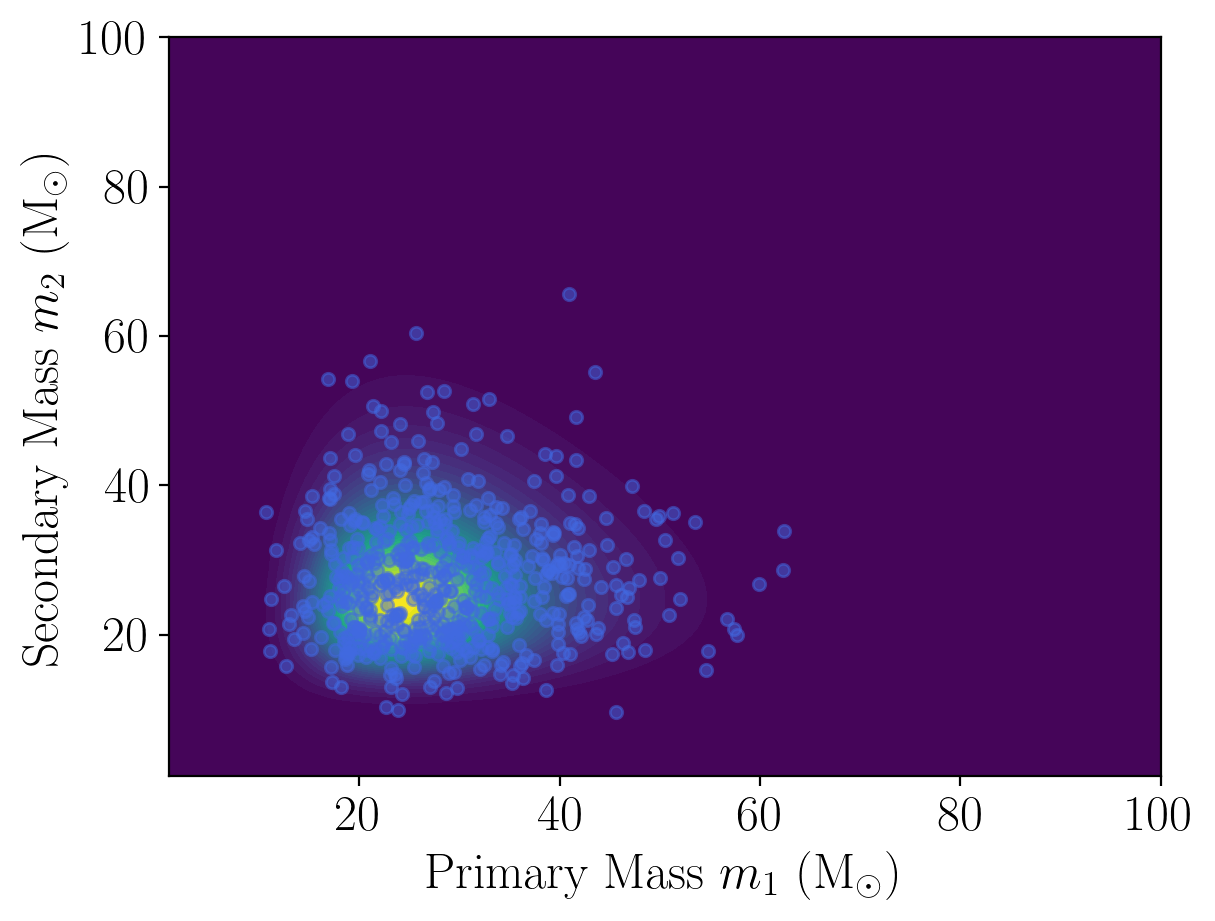

In [20]:
m1s = np.linspace(1, 100, 100)
m2s = np.linspace(1, 100, 100)
M1, M2 = np.meshgrid(m1s, m2s)
Z = mymassdist.mass_function(M1, M2)
plt.contourf(M1, M2, Z, levels=50, cmap='viridis')
plt.scatter(samples['m1_src'], samples['m2_src'], alpha=0.5, s=20, color='royalblue')
plt.xlabel('Primary Mass $m_1$ (M$_\\odot$)')
plt.ylabel('Secondary Mass $m_2$ (M$_\\odot$)')
plt.show()

### Redshift

In [21]:
# Shape parameters
z_hyperpars = {'alpha_z': 34.0 / 37.0}

# Normalization (a.k.a. local merger rate at z=0) in Gpc^-3 yr^-1
R0 = 1.0

MyRateDist = PBHMergerRateFunction(hyperparameters=z_hyperpars)

In [22]:
z_dict = MyRateDist.sample_population(size=600)

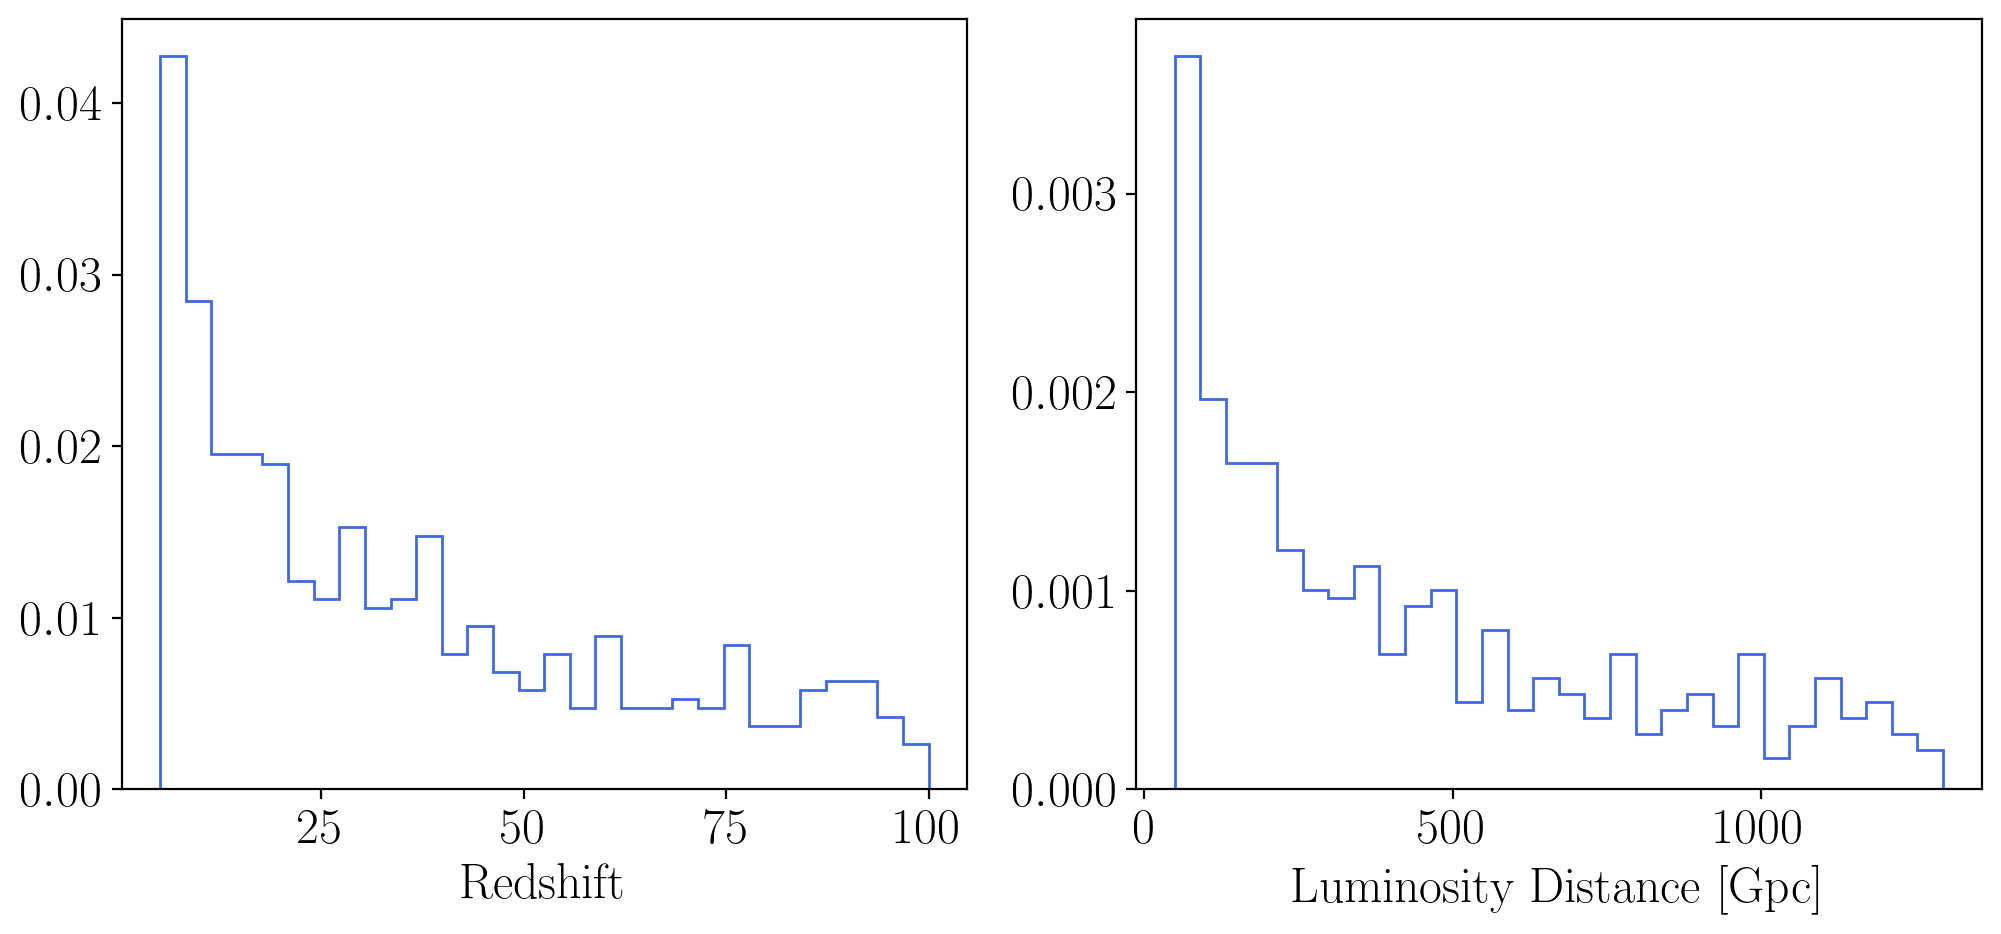

In [23]:
fig, axs = plt.subplots(1, 2, figsize=(12,5))

axs[0].hist(z_dict['z'], bins=30, density=True, histtype='step', lw=2, color='royalblue')
axs[0].set_xlabel('Redshift')
axs[1].hist(z_dict['dL'],bins=30, density=True, histtype='step', lw=2, color='royalblue')
axs[1].set_xlabel('Luminosity Distance $[\\rm{Gpc}]$')
plt.show()

(array([0.04272542, 0.02848361, 0.01951655, 0.01951655, 0.01898908,
        0.01213191, 0.01107696, 0.01529676, 0.01054949, 0.01107696,
        0.01476928, 0.00791212, 0.00949454, 0.00685717, 0.00580222,
        0.00791212, 0.00474727, 0.00896706, 0.00474727, 0.00474727,
        0.00527474, 0.00474727, 0.00843959, 0.00369232, 0.00369232,
        0.00580222, 0.00632969, 0.00632969, 0.00421979, 0.00263737]),
 array([ 5.13154087,  8.29125223, 11.45096359, 14.61067495, 17.77038631,
        20.93009767, 24.08980903, 27.24952038, 30.40923174, 33.5689431 ,
        36.72865446, 39.88836582, 43.04807718, 46.20778853, 49.36749989,
        52.52721125, 55.68692261, 58.84663397, 62.00634533, 65.16605669,
        68.32576804, 71.4854794 , 74.64519076, 77.80490212, 80.96461348,
        84.12432484, 87.28403619, 90.44374755, 93.60345891, 96.76317027,
        99.92288163]),
 [<matplotlib.patches.Polygon at 0x12bd25fd0>])

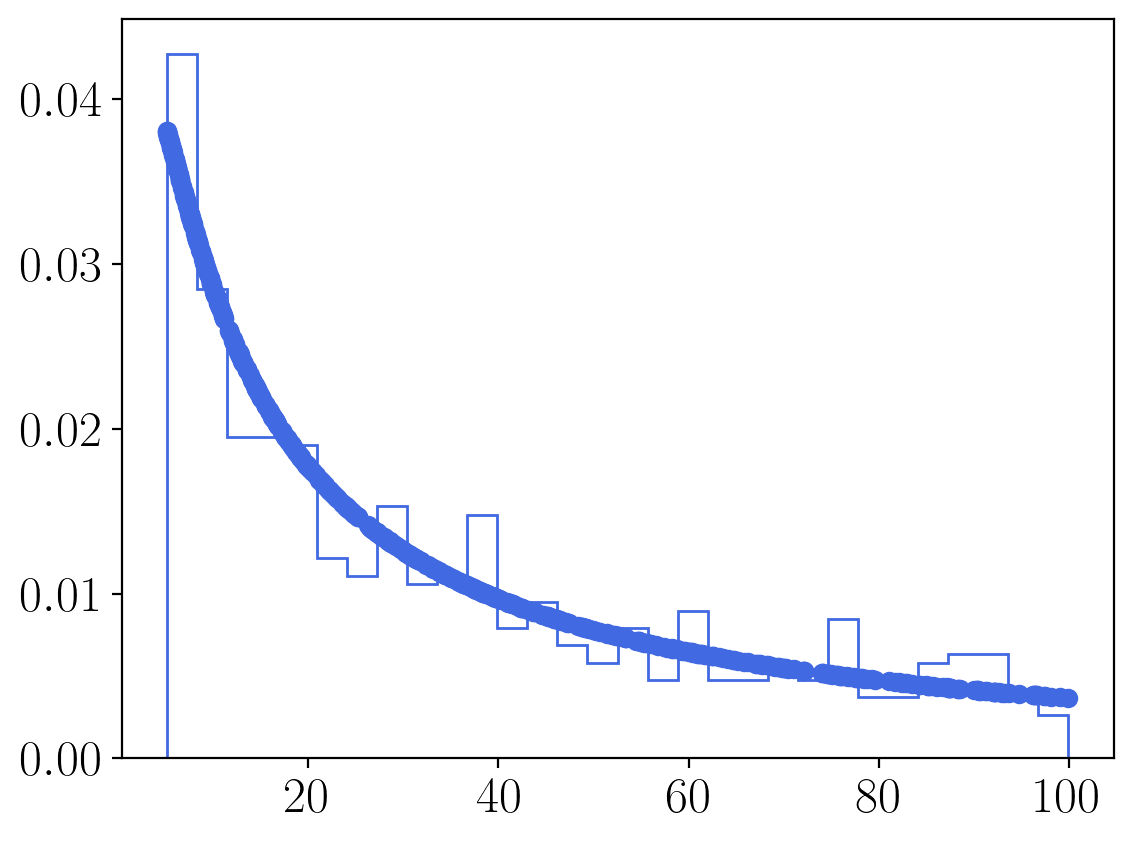

In [24]:
plt.scatter(z_dict['z'], MyRateDist.rate_function(z_dict['z']), color='royalblue')
plt.hist(z_dict['z'], bins=30, density=True, histtype='step', lw=2, color='royalblue')

### Spins

In [25]:
seed = 42
rng1 = np.random.default_rng(seed)

rng1 = np.random.default_rng(seed)
rng2 = np.random.default_rng(seed+1)

spin_dict = {'chi1': rng1.beta(a=1, b=100, size=600) * rng1.choice([-1, 1], size=600),
             'chi2': rng2.beta(a=1, b=100, size=600) * rng2.choice([-1, 1], size=600)}

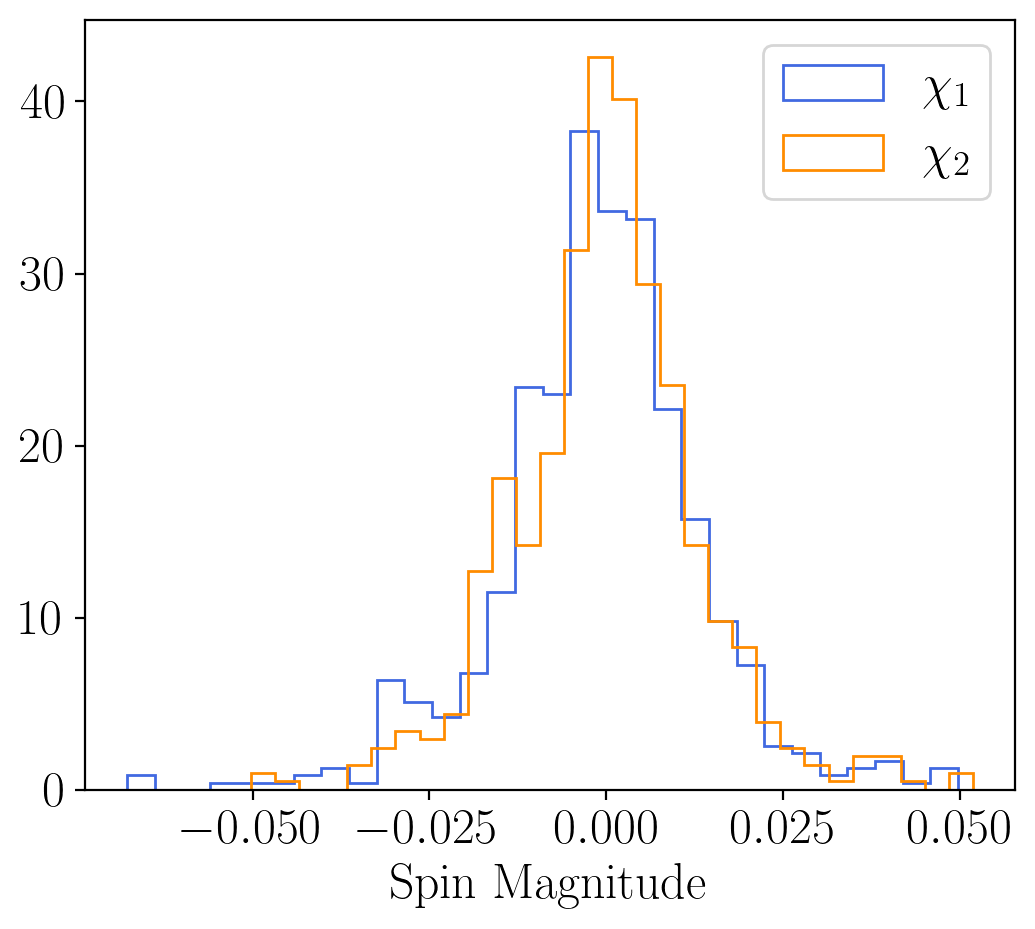

In [26]:
fig, axs = plt.subplots(1, 1, figsize=(6,5))

axs.hist(spin_dict['chi1'], bins=30, density=True, histtype='step', lw=2, color='royalblue',label='$\\chi_1$')
axs.hist(spin_dict['chi2'], bins=30, density=True, histtype='step', lw=2, color='darkorange',label='$\\chi_2$')
axs.set_xlabel('Spin Magnitude')
axs.legend()

plt.show()

## Converting into GWFast catalog

In [27]:
pop_dict = {**samples, **z_dict, **spin_dict}

Nevents = 600

# Sampling angular variables isotropically
rng_psi = np.random.default_rng(seed+2)
rng_thetaJN = np.random.default_rng(seed+3)
rng_theta = np.random.default_rng(seed+4)
rng_phi = np.random.default_rng(seed+5)

pop_dict['psi'] = rng_psi.uniform(0, np.pi, Nevents)
pop_dict['thetaJN'] = np.arccos(rng_thetaJN.uniform(-1, 1, Nevents))

pop_dict['theta'] = np.arccos(rng_theta.uniform(-1, 1, Nevents))
pop_dict['phi'] = rng_phi.uniform(0, 2*np.pi, Nevents)
pop_dict['ra'] = pop_dict['phi']
pop_dict['dec'] = np.pi/2. - pop_dict['theta']

# Sampling coalescence phase and time uniformly
rng_phicoal = np.random.default_rng(seed+6)
rng_tcoal = np.random.default_rng(seed+7)
pop_dict['Phicoal'] = rng_phicoal.uniform(0, 2*np.pi, Nevents)
pop_dict['tcoal'] = rng_tcoal.uniform(0, 1, Nevents)

# Computing Mc and eta in detector frame
m1_det = pop_dict['m1_src']*(1.+pop_dict['z'])
m2_det = pop_dict['m2_src']*(1.+pop_dict['z'])
pop_dict['Mc'] = ((m1_det*m2_det)**(3./5.))/((m1_det+m2_det)**(1./5.))
pop_dict['eta'] = (m1_det*m2_det)/((m1_det+m2_det)*(m1_det+m2_det))

pop_dict.keys()

dict_keys(['m1_src', 'm2_src', 'z', 'dL', 'chi1', 'chi2', 'psi', 'thetaJN', 'theta', 'phi', 'ra', 'dec', 'Phicoal', 'tcoal', 'Mc', 'eta'])

In [28]:
# Saving samples in a h5 file
import h5py
fname = 'PBH_cat_1yr.h5'
with h5py.File(fname, 'w') as out:
                
    def cd(n, d):
        d = np.array(d)
        out.create_dataset(n, data=d, compression='gzip', shuffle=True)
    
    for key in pop_dict.keys():
        cd(key, pop_dict[key])